# Yield Curve Construction

## Supporting Code

Below we have the code that support curve construction

1. first we import major libraries that we will use in the practical example

1. we define the helper class _MarketDataHandler_ which
    * Allows us to easily get data from our db
    * Create a yield curve function based on a set of nodes and an interpolation method
    * convert strings like 9Mo or 10Yr into float numbers representation in year
<br><br>

1. Define a vanilla IR model class that has valuation functions for various important quantity such as
    * Forward rates
    * Swap rates
<br><br>

1. Define the following class of Intruments
    * FRA single Curve & multicurve
    * IRS single Curve & multicurve
    
    

**Imports**

In [1]:
from abc import ABC, abstractmethod
from numpy import array, exp, log, ones_like, sqrt, linspace, arange, zeros_like, abs, mean, nan_to_num
import numpy as np
from math import pi as π
from scipy.stats import norm
from scipy.optimize import newton, brentq, minimize, root, fsolve
from scipy.integrate import quad, simpson, romberg, quad
import re
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import newton, brentq, minimize, basinhopping, shgo, brute, dual_annealing
from scipy.interpolate import splrep, splev, CubicSpline
from sqlalchemy import create_engine
from copy import deepcopy

**Market data handler**

In [2]:
class MarketDataHandler:
    def __init__(self):
        self.db_name = 'PyDB_prod'
        self.server_name = r"wbmsmc101\marketrisk"
        self.sql_driver = r"ODBC Driver 17 for SQL Server"
        self.connection_str = f"mssql+pyodbc://{self.server_name}/{self.db_name}?driver={self.sql_driver}"
        self.conn = create_engine(self.connection_str).connect()

    def get_yield_curve(self, date, currency, interpolation_type='spline'):
        sql = f""" SELECT Date,Node, [t],[Rate(%)] as r FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy]  where date = '{date}'  and CCY = '{currency}' Order by t """

        yield_curve_data = pd.read_sql(sql, self.conn)
        yield_curve_data['Date'] = yield_curve_data.Date.apply(lambda x: x.date())
        yield_curve_data['P(0,T)'] = exp(-yield_curve_data.r * yield_curve_data.t / 100.0)

        if interpolation_type == 'linear':
            y = lambda t: np.interp(t, yield_curve_data.t, yield_curve_data.r)

        else:
            interpolator = splrep(yield_curve_data.t, yield_curve_data.r)
            y = lambda t: splev(t, interpolator, der=0)

        return y, yield_curve_data

    def build_yield_curve(self, t, r, interpolation_type='spline'):

        if interpolation_type == 'linear':
            y = lambda T: np.interp(T, t, r)

        else:
            interpolator = splrep(t, r)
            y = lambda T: splev(T, interpolator, der=0)

        return y

    def get_yield_curve_lin(self, date, currency):
        sql = f""" SELECT Date,Node, [t],[Rate(%)] as r FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy]  where date = '{date}'  and CCY = '{currency}' Order by t """

        yield_curve_data = pd.read_sql(sql, self.conn)
        yield_curve_data['Date'] = yield_curve_data.Date.apply(lambda x: x.date())
        yield_curve_data['P(0,T)'] = exp(-yield_curve_data.r * yield_curve_data.t / 100.0)
        interpolator = splrep(yield_curve_data.t, yield_curve_data.r)
        y = lambda t: np.interp(t, yield_curve_data.t, yield_curve_data.r)
        return y, yield_curve_data
    
    def to_time(self, x):
        m = re.split('^([0-9]+)', x)

        if m[2] == 'Mo':
            return float(m[1]) / 12

        if m[2] == 'Yr':
            return float(m[1])





**Interest Rate model**

In [3]:
class VanillaIR():
    model_name = 'VanillaIR'

    def __init__(self, curve):
        self.y = curve
        self.ϵ = 0.000001
         
    # market zero coupon bond curve
    def P0T_market(self, T):
        return exp(-self.y(T) / 100 * T)

    # value of P(t,T) bond based on the market
    def P_market(self, t, T):
        return self.P0T_market(T) / self.P0T_market(t)


    # value of Forward rate based on the market
    def F_market(self, t, T, S):
        τ = S - T
        return 1 / τ * (self.P_market(t, T) / self.P_market(t, S) - 1)

    # value of instantaneous Forward rate based on the market
    def f_market(self, t, T):
        ε = self.ε / 2
        T = T + ε * 2
        return -(log(self.P_market(t, T + ε)) - log(self.P_market(t, T - ε))) / (2 * ε)

    # Continous compounding rate based on market
    def R_market(self, t, T):
        pass

    # libor forward rate based on the market
    def L_market(self, t, T):
        return (1 - self.P_market(t, T)) / ((T - t) * self.P_market(t, T))

    def S_α_β_market(self, t, T, τ):
        P = self.P_market

        T_α = T[0] - τ
        T_β = T[-1]
        S = (P(t, T_α) - P(t, T_β)) / sum(τ * P(t, T))
        return S

    def F(self, t, T, S):
        P = self.P

        τ = S - T
        return 1 / τ * (P(t, T) / P(t, S) - 1)

    def S_α_β(self, t, T, τ):
        """

        :param t: valuation date
        :param T: array of payment dates
        :param τ: time between reset date and payment date
        :return:
        """
        P = self.P

        T_α = T[0] - τ
        T_β = T[-1]
        S = (P(t, T_α) - P(t, T_β)) / sum(τ * P(t, T))
        return S

    def zero_coupon_to_yield(self, T, z):
        return -log(z) / T * 100

    def P(self, t, T):
        """
        :param t: valuation date
        :param T: Payment date of ZCB
        :return:
        """
        return self.P_market(t,T)


**Define FRA and IRS classes**

In [4]:
def get_cf_schedule(t , To, T, τ):
    """
    t = todays date
    To = contract start date
    T = contract Maturity
    τ = period between payments
    """
    schedule_raw = arange(0+τ,T+τ, τ)    
    schedule_raw_2 = schedule_raw[schedule_raw > To]
    schedule_cf = schedule_raw_2[schedule_raw_2 > t]
    
    return schedule_cf

class Instrument(ABC):

    def __init__(self, model: VanillaIR):
        self.model = model
        pass

    @abstractmethod
    def PV(self):
        pass

class LinearInstrument(Instrument, ABC):
    pass


class FRA(LinearInstrument):
    """
    Class used to price floating rate agreements
    """

    def PV(self, t, T, S, N, K, fra_type='R'):
        """

        :param t: Valuation date
        :param T: Reset date
        :param S: Payment date
        :param N: Notional
        :param K: Strike rate
        :param fra_type: if R then receive fixed rate else Pay
        :return:
        """

        P = self.model.P
        F = self.model.F

        τ = S - T
        α = 1 if fra_type == 'R' else -1
        return N * P(t, S) * τ * (K - F(t, T, S)) * α
    
class Multicurve_FRA(LinearInstrument):
    """
    Class used to price floating rate agreements
    """
    
    def __init__(self, model: VanillaIR, discount_model: VanillaIR ):
        LinearInstrument.__init__(self, model)
        self.discount_model = discount_model

    def PV(self, t, T, S, N, K, fra_type='R'):
        """
        :param t: Valuation date
        :param T: Reset date
        :param S: Payment date
        :param N: Notional
        :param K: Strike rate
        :param fra_type: if R then receive fixed rate else Pay
        :return
        """
        
        P = self.discount_model.P
        F = self.model.F

        τ = S - T
        α = 1 if fra_type == 'R' else -1
        return N * P(t, S) * τ * (K - F(t, T, S)) * α

class IRS(LinearInstrument):

    def __init__(self, model: VanillaIR):
        LinearInstrument.__init__(self, model)
        self.fra = FRA(model)

    def PV(self, t, T, τ, N, K, irs_type='R'):
        """
        t : valuation date
        T : array of payment dates
        τ : year fraction floating index
        N : Notional
        K : Swap Rate
        """

        FRA = self.fra.PV

        return sum(FRA(t, T - τ, T, N, K, fra_type=irs_type))

class MultiCure_IRS(LinearInstrument):

    def __init__(self, model: VanillaIR, discount_model: VanillaIR):
        LinearInstrument.__init__(self, model)
        
        self.fra = Multicurve_FRA(model = model, discount_model = discount_model)

    def PV(self, t, T, τ, N, K, irs_type='R'):
        """
        t : valuation date
        T : array of payment dates
        τ : year fraction floating index
        N : Notional
        K : Swap Rate
        """

        FRA = self.fra.PV

        return sum(FRA(t, T - τ, T, N, K, fra_type=irs_type))

## Single Curve framework

1. A yield curve can be expressed as a set of nodes  $\Omega_{yc} = \left\{ (t_1, r_1), (t_2, r_2),..., (t_n, r_n) \right\} $

1. the set of points in $\Omega_{yc}$ are called spine points

1. To create a yield curve we chosse a set of linear calibration instruments whose value in the market are known : the value of the ith instument is denoted $V^{market}_i$

1. Each instument value is a function of the the yield curve node $\Omega_{yc}$ that is : the value of the  ith istrument is denoted $V^{model}_i(\Omega_{yc})$ 

1. In the calibration process we find the set of rates such that the error is minimized that is $$ \left\| \mathbf{V}^{market} - \mathbf{V}^{model}\right\|_L = 0$$

### example: creating swap curve based on a set of swap quotes

Minimized sum squared error = 6.422492665154284e-21 


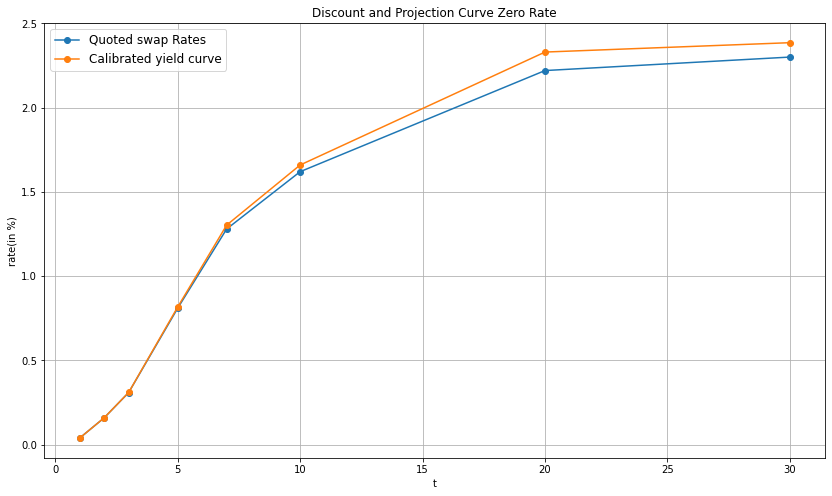

As we can see each swap is priced fairly when we use the calibrated rates 

----------------------
 Swap0 pv = 2.5409223336492204e-12 
Swap rate 0 = 0.0003999999999747153
K[0] = 0.0004

----------------------
 Swap1 pv = -1.271975580419138e-11 
Swap rate 1 = 0.001600000000063809
K[1] = 0.0016

----------------------
 Swap2 pv = 1.598166043947913e-11 
Swap rate 2 = 0.003099999999946706
K[2] = 0.0031

----------------------
 Swap3 pv = -2.5632107547579608e-11 
Swap rate 3 = 0.008100000000051956
K[3] = 0.008100000000000001

----------------------
 Swap4 pv = 4.580558154998471e-12 
Swap rate 4 = 0.01279999999999334
K[4] = 0.0128

----------------------
 Swap5 pv = -2.1039753272944495e-11 
Swap rate 5 = 0.016200000000022335
K[5] = 0.016200000000000003

----------------------
 Swap6 pv = 6.629369275756858e-11 
Swap rate 6 = 0.022199999999960526
K[6] = 0.0222

----------------------
 Swap7 pv = -2.1984525311324887e-11 
Swap rate 7 = 0.02300000000000993
K[7] = 0.023


In [5]:
md = MarketDataHandler()

# Swap rate terms and 
r0 = array([0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01])   
K   = array([0.04/100.0,0.16/100.0,	0.31/100.0,	0.81/100.0,	1.28/100.0,	1.62/100.0,	2.22/100.0,	2.30/100.0])
mat = array([1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0])
τ = 0.25

# DEFINE INSTRUMENTS the list of instuments
instruments = [lambda model, i=i : IRS(model).PV( t = 0, T = arange(τ, mat[i] + τ, τ), τ = τ, N= 100, K= K[i] ) for i in range(len(K)) ]

def yield_curve(instruments, mat, r0):
    """
    This function takes as input
        * an array of instruments 
        * array of maturity date for the instruments
        * initial guess of the yield curve r0
        
    from these input find the optimal set of rates such that the intrumnets 
    are priced with minimal errors
    """
    
    def f(params):
        sum_squared_error = 0.0
        v = VanillaIR(curve=md.build_yield_curve(t=mat, r= params))
        for i, instrument in enumerate(instruments):
            err = (instruments[i](v) - 0)**2
            sum_squared_error = sum_squared_error + err
        return sum_squared_error

    res = minimize(f, r0, method='Powell',tol= 10.0 ** -15)
    print(f"Minimized sum squared error = {res.fun} ")
    return res.x

x = yield_curve(instruments, mat, r0)
v =  VanillaIR( curve=md.build_yield_curve(t=mat, r= x))
    
    
fig = plt.figure(figsize=(14,8))
plt.grid()
plt.xlabel('t')
plt.ylabel('rate(in %)')
plt.plot(mat, K*100, linestyle='-', marker='o', label='Quoted swap Rates')
plt.plot(mat, x, linestyle='-',  marker='o', label='Calibrated yield curve')
plt.title('Discount and Projection Curve Zero Rate')
plt.legend(fontsize='large')
plt.show()


print("As we can see each swap is priced fairly when we use the calibrated rates ")
for i, ins in enumerate(instruments):
    print("\n----------------------")
    print(f" Swap{i} pv = {IRS(v).PV(t = 0, T = arange(τ, mat[i] + τ, τ), τ = τ, N= 100, K= K[i])} ")
    print(f"Swap rate {i} = {v.S_α_β_market(t = 0, T = arange(τ, mat[i] + τ, τ), τ = τ  )}")
    print(f"K[{i}] = {K[i]}")


## Multi-Curve Framework

### High level notes

1. New concepts fresh in financial mathematics 
1. Multicurve include extra information to include couterparty credit risk 
1. Naturally the credit risk depends on the tenor of the index being exchanged
1. we can have different curve for different tenors
1. Basis swap a contract where float - float is being exchanged the only difference being the tenor
1. before 2008 the basis spread where close to zero by now they are not neglibible ( we can think of the spread as being due to liquidity and credit risk premia)
1. The classical machinery of measure change does not work well in multi curve framework
1. Extensions/modified definition of libor rate (based on the discount curve) needs to be made for our machinery to work again
1. to do this we need to include the concepts of default propability
1. link with default probabilities : Hazards rates  -- wish can be calibrated from CDS
1. new "risky libor" adjustement
1. estimtation meaure change
1. circular dependency case : when need to use basis spread insruments like OIS-3M

### detailed Grezlak Notes

1. when lendeing for 1m there is less risk of default than lending for 6M. this is the issue multi curve try to solve <br>

1. Basis swap contract <br>
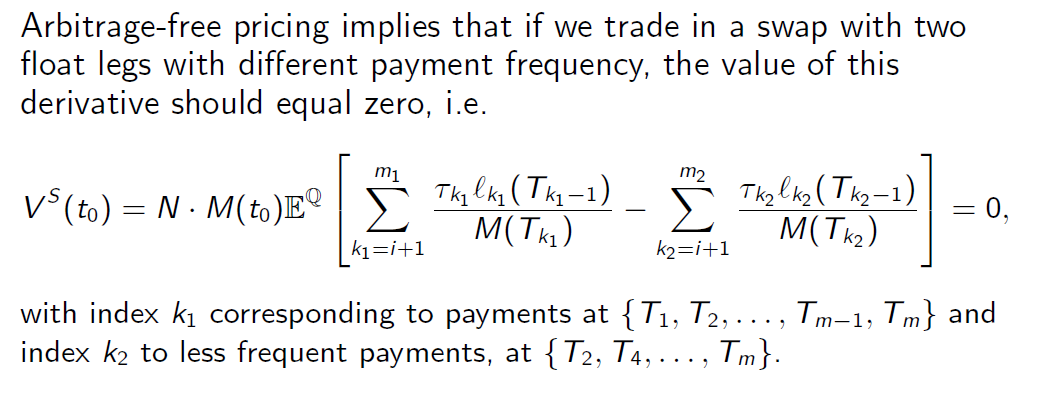 <br>
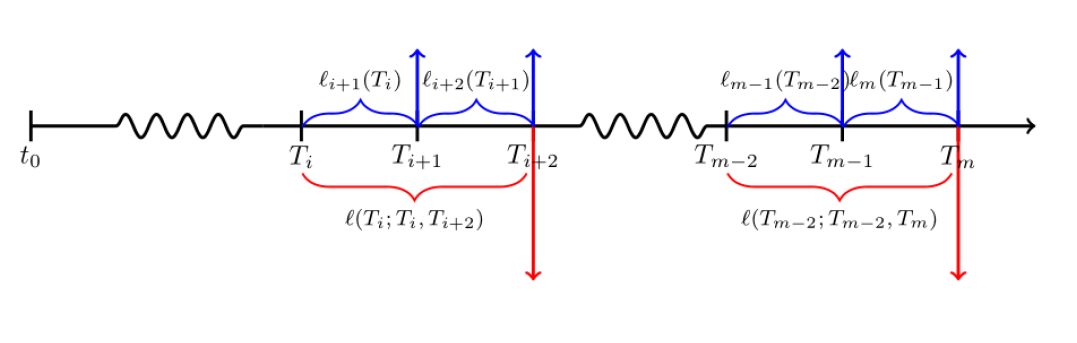<br>

1. Untill 2008 basis spread was close to zero <br>

1. However now the different tenor has liquidity and risk premium <br>

1. Note under multi curve framework no-arbitrage relation do not hold anymore <br>
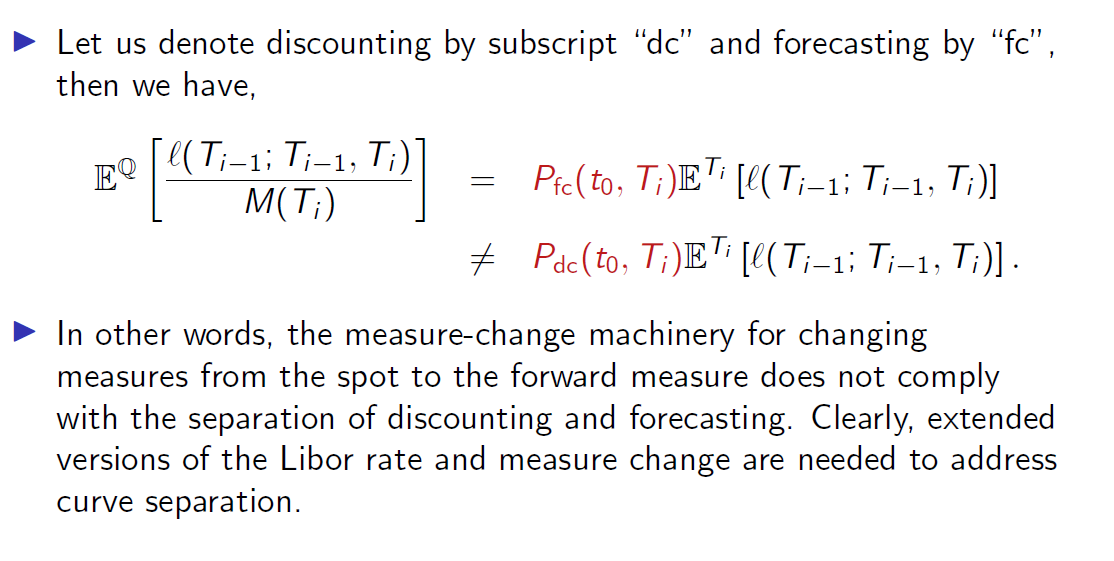<br>

1. include default <br>
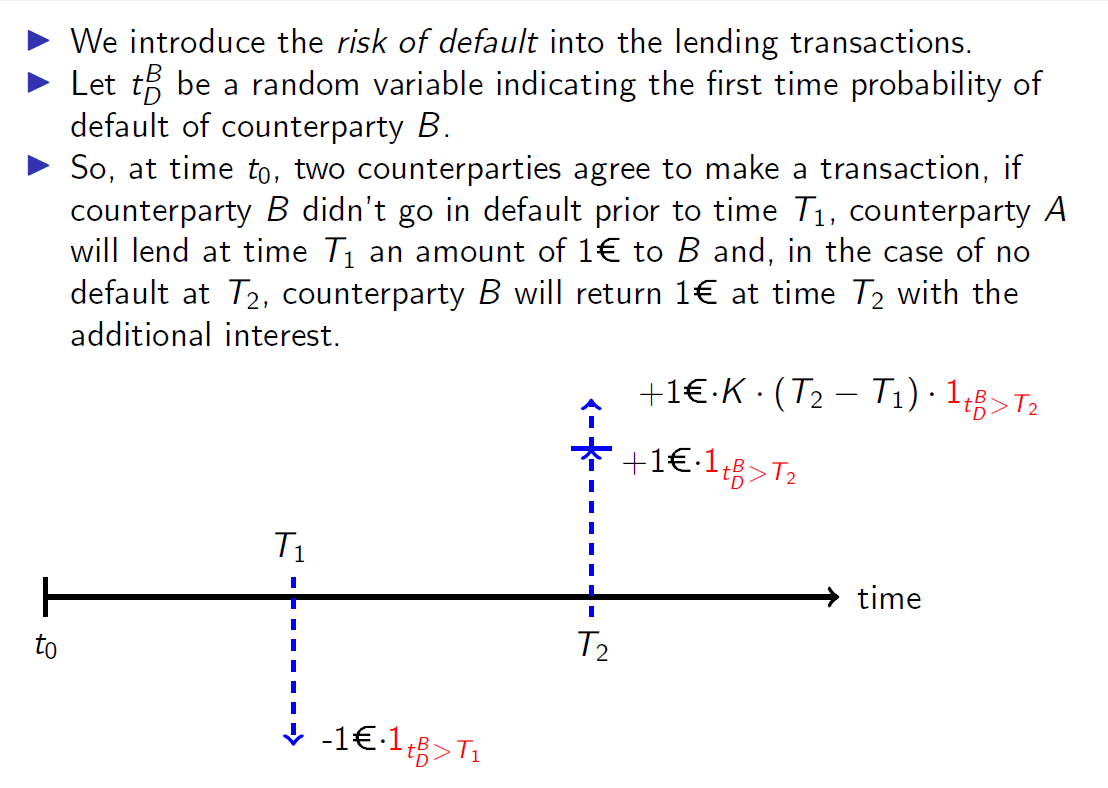 <br>

1. hazard rate role <br>
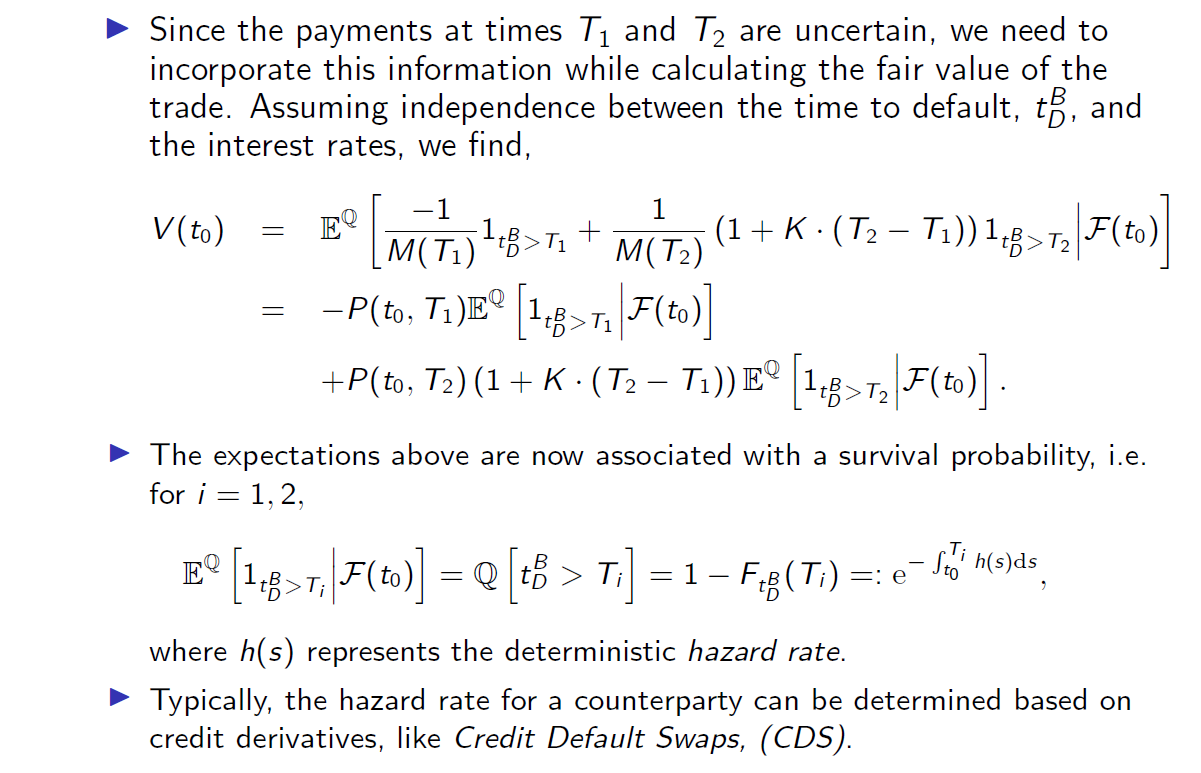 <br>

1. risk Libor : the idea is that we have an extract discount factor for the libor cashflows to account for the risk. and that risk will depend on the periodicity<br>
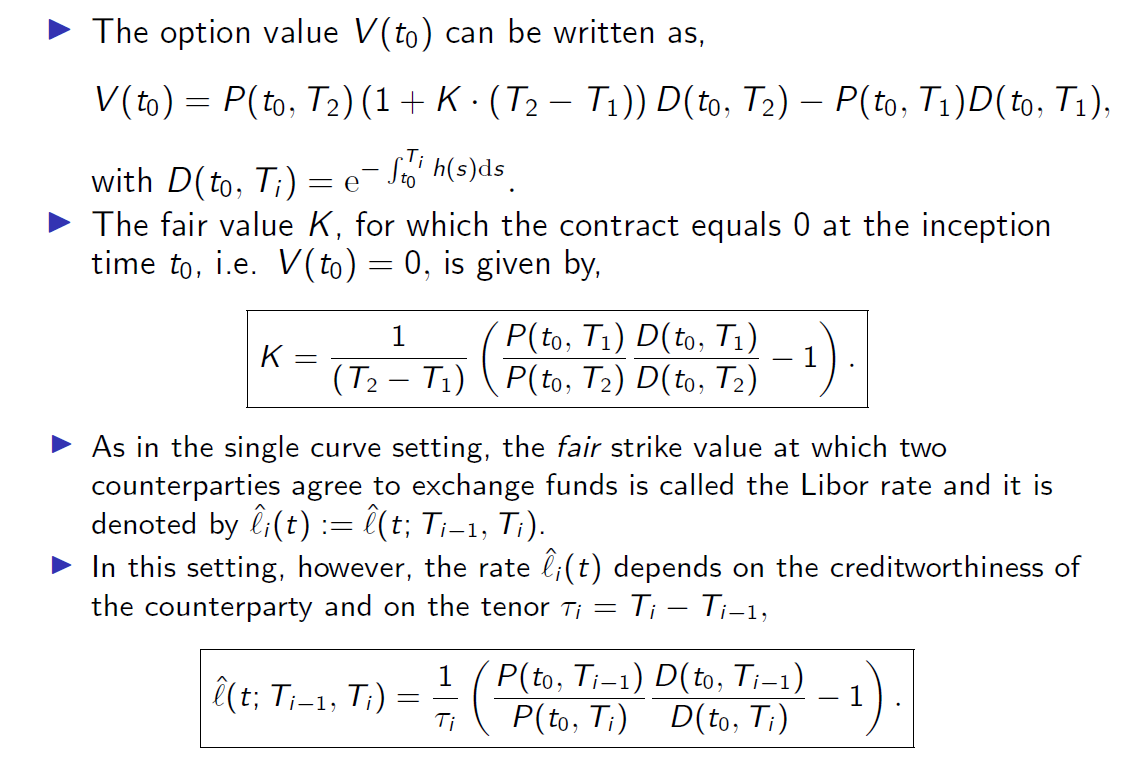 <br>
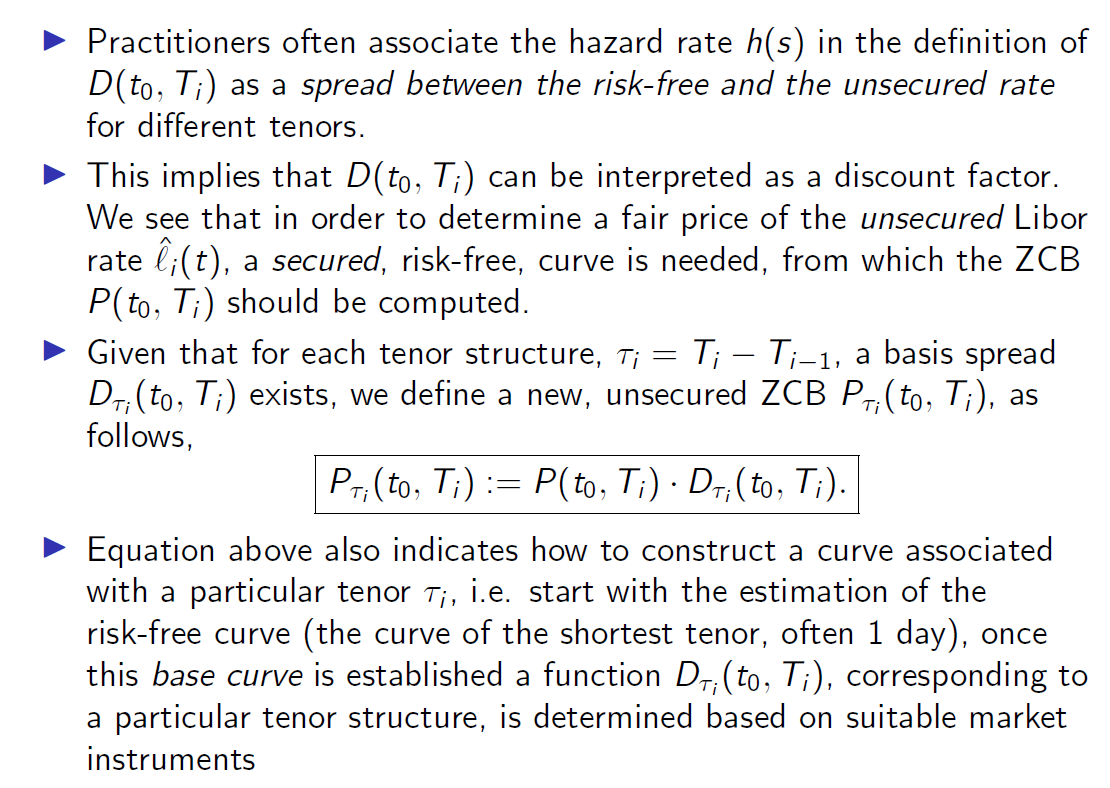 <br>
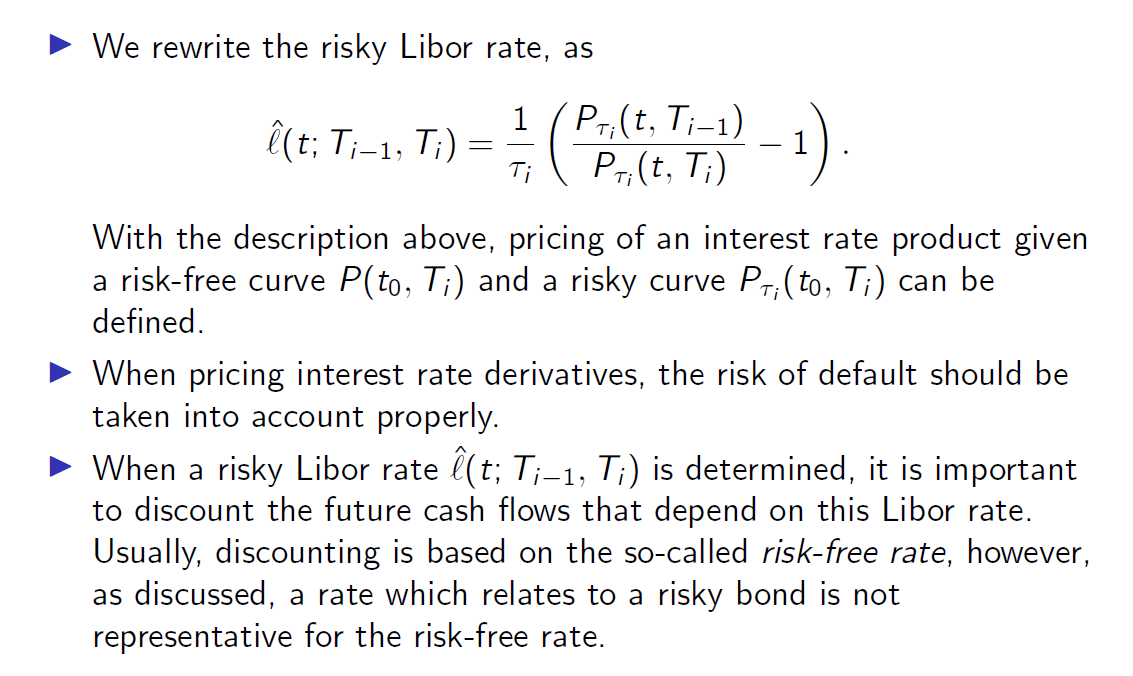 <br>

1. pricing swaps under multi curve framework <br>
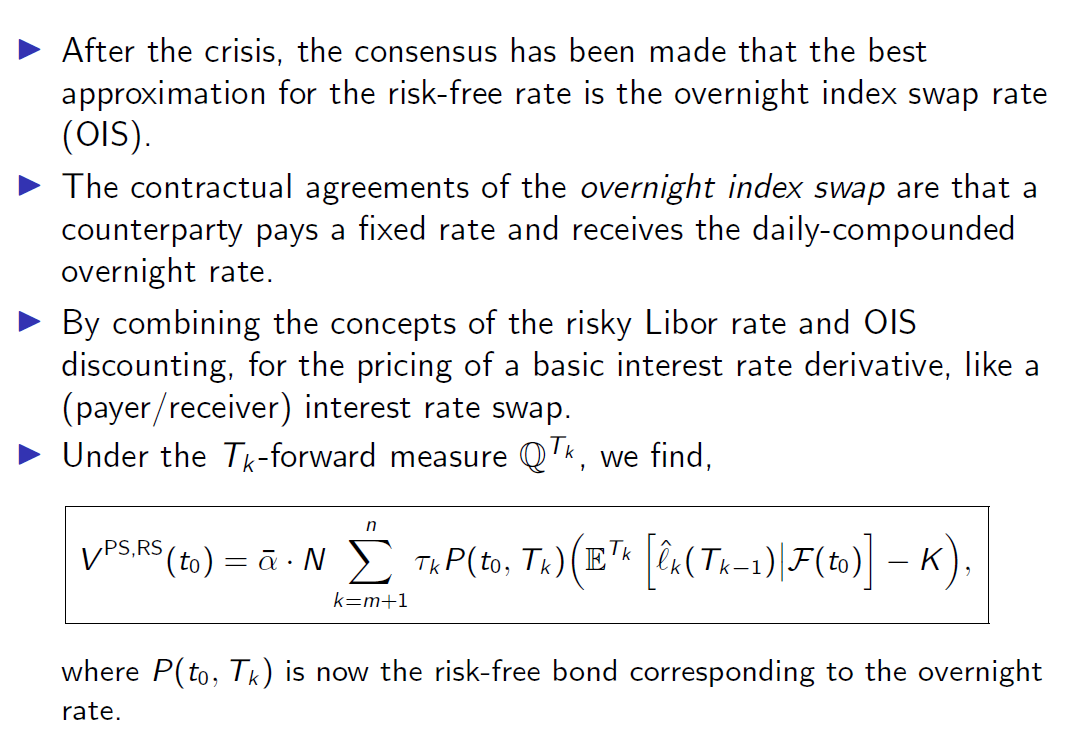 <br>
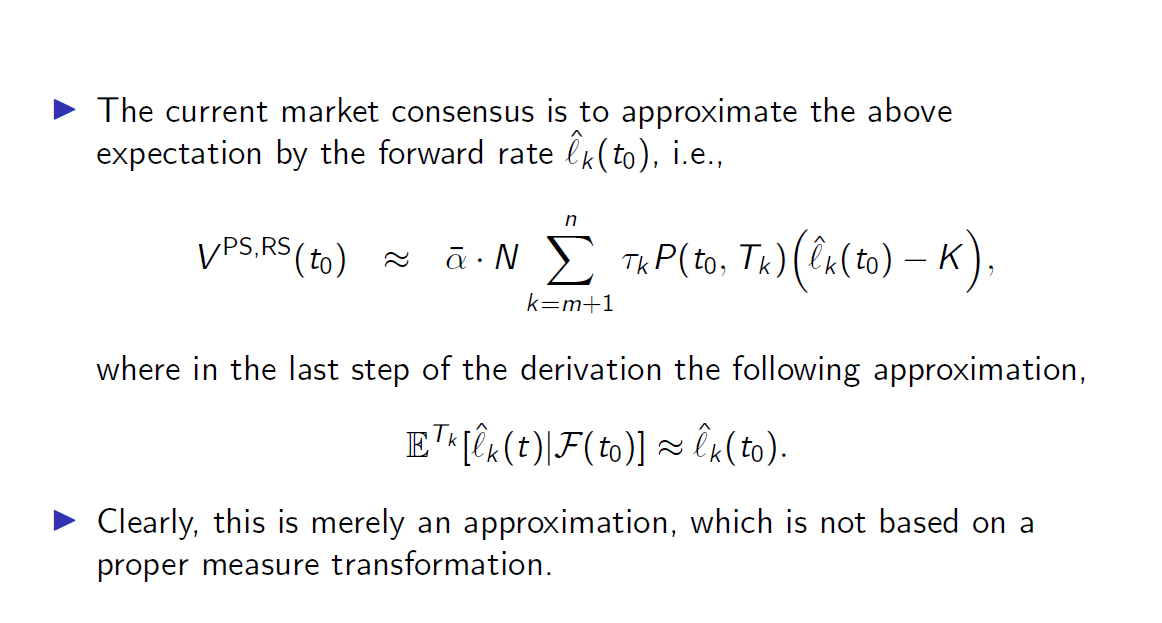 <br>

1. Circular dependency <br>
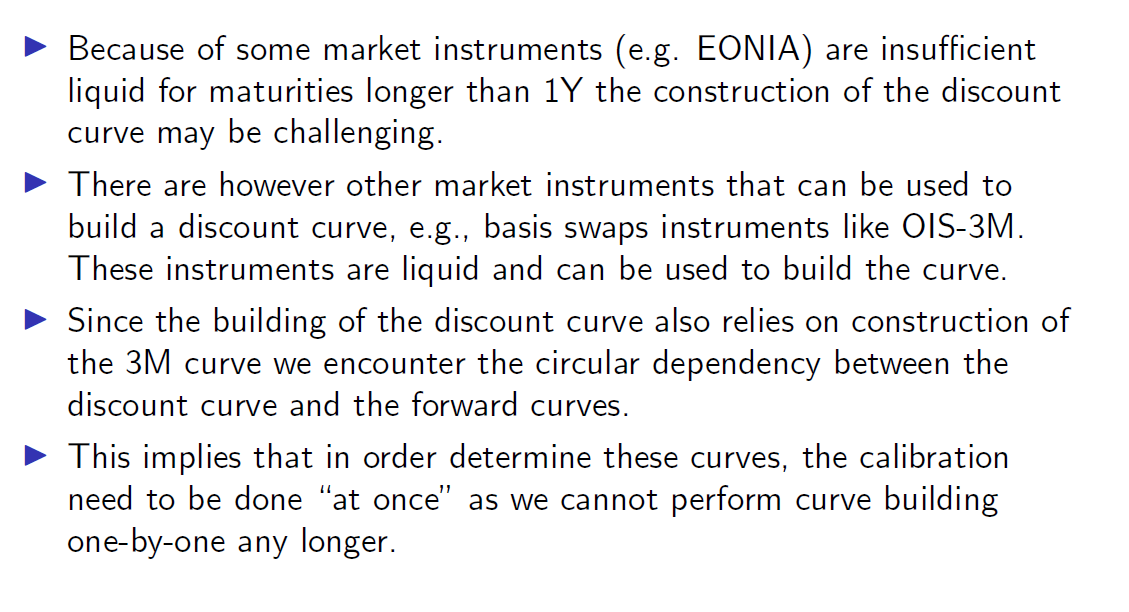 <br>
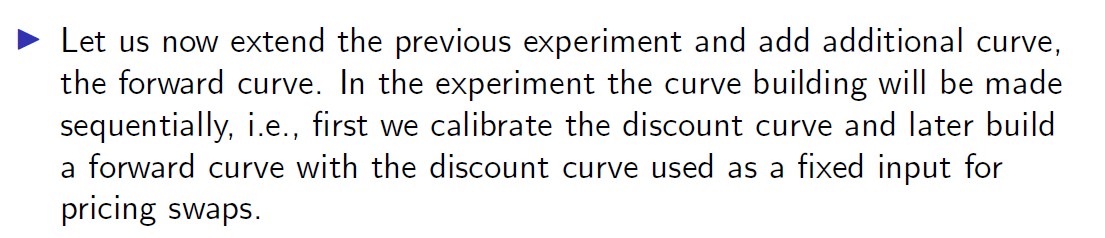 <br>

### Example

Here we show example of calibration in the multi curve framework

1. we have OIS swap rates quotes that would be used to first calibrate an OIS curve that would be used for discounting

2. then we use the forecasting swap rate quotes along with the discounting OIS curve to calibrate the forecasting curve

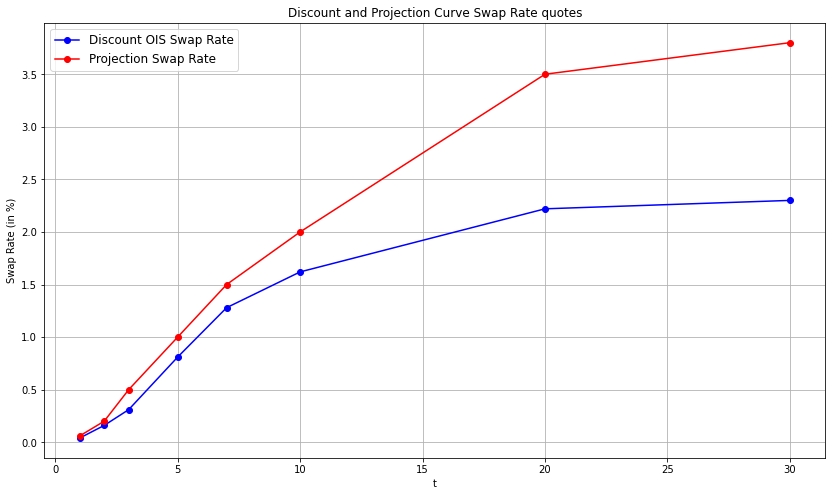

Minimized sum squared error = 6.422492665154284e-21 
Minimized sum squared error = 2.1486173373797323e-21 


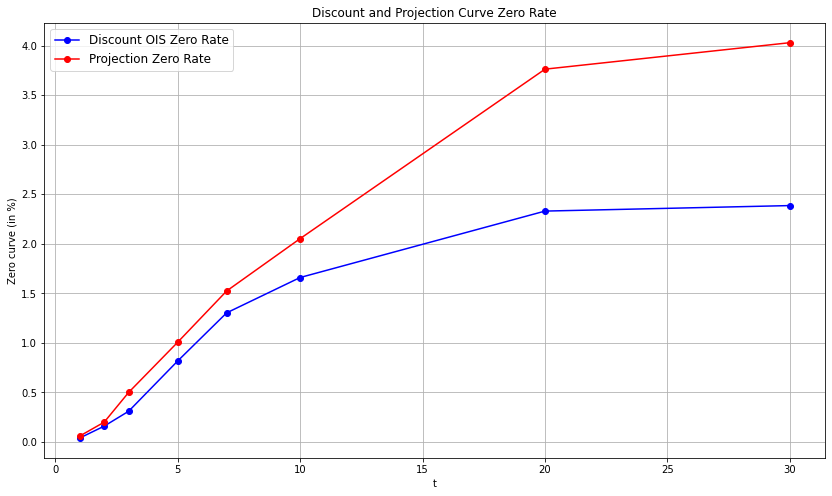

In [6]:
# Swap rate terms for discount curve
mat_OIS = array([1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0])
K_OIS = array([0.04/100.0,0.16/100.0,	0.31/100.0,	0.81/100.0,	1.28/100.0,	1.62/100.0,	2.22/100.0,	2.30/100.0])
r0_OIS = array([0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01])   

# Swap rate terms for projection curve
mat_Frwd = array([1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0])
K_Frwd = array([0.06/100.0,0.2/100.0,	0.5/100.0,	1/100.0,	1.5/100.0,	2/100.0,	3.5/100.0,	3.8/100.0])
r0_Frwd = array([0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01]) 
τ = 0.25

# plot discount curve swap rates 
fig = plt.figure(figsize=(14,8))
plt.grid()
plt.xlabel('t')
plt.ylabel('Swap Rate (in %)')
plt.plot(mat_OIS, K_OIS*100, linestyle='-', color='b', marker='o', label='Discount OIS Swap Rate')
plt.plot(mat_Frwd, K_Frwd*100, linestyle='-', color='r', marker='o', label='Projection Swap Rate')
plt.title('Discount and Projection Curve Swap Rate quotes')
plt.legend(fontsize='large')
plt.show()


# First get the discount curve zero rates
ois_instruments = [lambda model,i=i :
                   IRS(model).PV(
                       t = 0,
                       T = arange(τ, mat_OIS[i] + τ, τ),
                       τ = τ,
                       N= 100,
                       K= K_OIS[i]  
                   ) 
               for i in range(len(K_OIS))
              ]
r_ois = yield_curve(ois_instruments, mat_OIS, r0_OIS)
r_ois_model = VanillaIR(curve=md.build_yield_curve(t=mat_OIS, r= r_ois))

# then get the forward curve zero rates 
frwrd_instruments = [lambda model, i=i :
                   MultiCure_IRS(model=model, discount_model=r_ois_model).PV(
                       t = 0,
                       T = arange(τ, mat_Frwd[i] + τ, τ),
                       τ = τ,
                       N= 100,
                       K= K_Frwd[i]  
                   ) 
               for i in range(len(K_Frwd))
              ]
r_frwrd = yield_curve(frwrd_instruments, mat_Frwd, r0_Frwd)


fig = plt.figure(figsize=(14,8))
plt.grid()
plt.xlabel('t')
plt.ylabel('Zero curve (in %)')
plt.plot(mat_OIS, r_ois, linestyle='-', color='b', marker='o', label='Discount OIS Zero Rate')
plt.plot(mat_Frwd, r_frwrd, linestyle='-', color='r', marker='o', label='Projection Zero Rate')
plt.title('Discount and Projection Curve Zero Rate')
plt.legend(fontsize='large')
plt.show()




